# 03 — Original-quality face verification baseline

**Goal:** measure verification performance before any synthetic degradation.

Use the working Commit 4 environment. This notebook adds no dependency pins. Review development crops before proceeding; keep the selected model, preprocessing, and threshold rule fixed during evaluation.

The supplied 6,000 pairs retain their 10 folds. For each fold, a threshold is fitted on successfully scored pairs from the other nine folds and evaluated on the held-out fold. Only thresholds are fitted; the face model is frozen.


In [1]:
from pathlib import Path
import sys
import json

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src/baseline_verification.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Launch Jupyter inside biometrics-project1.')
sys.path.insert(0, str(ROOT / 'src'))
from baseline_verification import run_baseline
print('Python executable:', sys.executable)
print('Python version:', sys.version)


Python executable: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification/.venv/bin/python
Python version: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]


## 1. Run the full baseline
This can take tens of minutes or longer on CPU. Each unique image is processed once. Progress is printed every 50 images. Keep several GB of free space for cached face crops and embeddings.

To resume an interrupted run, rerun this cell. Matching image hashes, model weights, preprocessing code, environment, and cache payload hashes are required for reuse. The manifest is saved every 25 images, so an interruption may repeat up to 24 completed images. Failed detections are cached under the same configuration too.

The report starts with `status=started`; an interrupted or failed run is not a completed baseline. Later output files may remain from an earlier run: rely on the latest summary status and output hashes.


In [2]:
report = run_baseline(ROOT)
if report['status'] != 'completed':
    raise RuntimeError('Baseline did not complete.')
a = report['aggregate']
print(f"Unique images: {report['unique_images']}")
print(f"Successful images: {report['successful_images']}")
print(f"Failed images: {report['failed_images']}")
print(f"Scored pairs: {a['scored_pairs']} / {a['requested_pairs']}")
print(f"Excluded pairs: {a['excluded_pairs']}")
print(f"Pair coverage: {100*a['coverage']:.2f}%")
print(f"Mean fold accuracy: {100*a['mean_accuracy']:.3f}%")
print(f"Accuracy standard deviation: {100*a['sd_accuracy']:.3f} percentage points")
print(f"Accuracy standard error: {100*a['se_accuracy']:.3f} percentage points")
print(f"Mean fold FMR: {100*a['mean_fmr']:.3f}%")
print(f"Mean fold FNMR: {100*a['mean_fnmr']:.3f}%")
print(f"Elapsed time: {report['elapsed_seconds']/60:.1f} minutes")


Loading the fixed face model on CPU ...


50/7701 images | reused 50 | elapsed 0.0 min


100/7701 images | reused 100 | elapsed 0.0 min


150/7701 images | reused 150 | elapsed 0.0 min


200/7701 images | reused 200 | elapsed 0.0 min


...

7650/7701 images | reused 7650 | elapsed 0.2 min


7700/7701 images | reused 7700 | elapsed 0.2 min


7701/7701 images | reused 7701 | elapsed 0.2 min


Saved results/metrics/baseline_summary.json


Unique images: 7701
Successful images: 7700
Failed images: 1
Scored pairs: 5999 / 6000
Excluded pairs: 1
Pair coverage: 99.98%
Mean fold accuracy: 99.167%
Accuracy standard deviation: 0.593 percentage points
Accuracy standard error: 0.188 percentage points
Mean fold FMR: 0.433%
Mean fold FNMR: 1.234%
Elapsed time: 0.2 minutes


## 2. Review fold results
All recognition rates below condition on pairs with usable embeddings. FMR = false matches / scored different-person pairs. FNMR = false non-matches / scored same-person pairs. Accuracy = correct decisions / scored pairs. A similarity equal to the threshold is accepted.

Each threshold maximizes calibration accuracy, considering midpoints between distinct calibration scores and endpoints for accepting or rejecting all. Ties choose the largest candidate threshold. Test scores and labels never select their own fold's threshold.

If either class has no valid calibration or test scores, evaluation stops with an explicit error instead of reporting an undefined rate as zero.


In [3]:
print('Fold  Threshold  Scored/Requested  Accuracy    FMR      FNMR')
for row in report['folds']:
    print(f"{row['fold']+1:4d}  {row['threshold']:9.5f}  "
          f"{row['scored_pairs']:4d}/{row['requested_pairs']:<9d}  "
          f"{100*row['accuracy']:7.3f}%  {100*row['fmr']:6.3f}%  {100*row['fnmr']:6.3f}%")
print('Image outcomes:')
print(json.dumps(report['image_status_counts'], indent=2))


Fold  Threshold  Scored/Requested  Accuracy    FMR      FNMR
   1    0.40351   600/600         99.500%   0.333%   0.667%
   2    0.40351   599/600         99.666%   0.000%   0.669%
   3    0.41555   600/600         98.500%   0.667%   2.333%
   4    0.40351   600/600         98.333%   1.000%   2.333%
   5    0.40351   600/600         98.833%   0.667%   1.667%
   6    0.40351   600/600         99.500%   0.000%   1.000%
   7    0.42305   600/600         98.333%   0.333%   3.000%
   8    0.40316   600/600         99.667%   0.667%   0.000%
   9    0.41555   600/600         99.667%   0.333%   0.333%
  10    0.40351   600/600         99.667%   0.333%   0.333%
Image outcomes:
{
  "ok": 7700,
  "low_detection_probability": 1
}


## 3. Plot original-condition metrics
The bars show held-out results per fold, using that fold's separately calibrated threshold. Fold-to-fold variability is descriptive; folds can share identities and their calibration sets overlap. Do not treat the reported standard error as a universal deployment confidence guarantee.


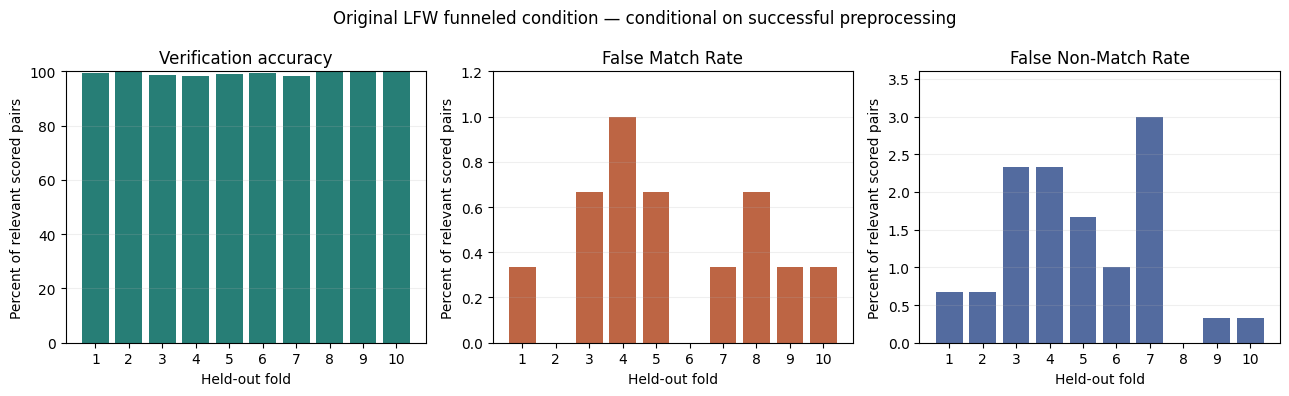

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fold_numbers = [row['fold'] + 1 for row in report['folds']]
for ax, key, title, color in zip(axes, ['accuracy', 'fmr', 'fnmr'],
                                ['Verification accuracy', 'False Match Rate', 'False Non-Match Rate'],
                                ['#277e76', '#bd6544', '#536b9f']):
    values = [100*row[key] for row in report['folds']]
    ax.bar(fold_numbers, values, color=color)
    ax.set_title(title)
    ax.set_xlabel('Held-out fold')
    ax.set_ylabel('Percent of relevant scored pairs')
    ax.set_xticks(fold_numbers)
    ax.grid(axis='y', alpha=.2)
    if key == 'accuracy':
        ax.set_ylim(0, 100)
    else:
        ax.set_ylim(0, max(1, max(values)*1.2))
fig.suptitle('Original LFW funneled condition — conditional on successful preprocessing')
fig.tight_layout()
figure_dir = ROOT / 'results/figures'
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / 'baseline_fold_metrics.png', dpi=160)
plt.show()


## 4. Inspect failure coverage separately
The CSV contains all requested pairs, including failures. Conditional metrics alone can look better when hard images are excluded. The following rows show genuine/impostor coverage and an explicit hypothetical operational policy: reject any comparison whose preprocessing fails.

That policy includes failed genuine attempts in its genuine rejection rate; this is separate from the scored-pair FNMR above. It is not a claim about the behavior of a deployed system.


In [5]:
for row in report['folds']:
    print(f"Fold {row['fold']+1}: genuine coverage={100*row['genuine_coverage']:.2f}%, "
          f"impostor coverage={100*row['impostor_coverage']:.2f}%, "
          f"reject-on-failure genuine rejection={100*row['reject_on_failure_genuine_rejection_rate']:.2f}%")
print('Detailed image outcomes: results/metrics/baseline_images.json')
print('Every held-out decision: results/metrics/baseline_predictions.csv')


Fold 1: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=0.67%
Fold 2: genuine coverage=99.67%, impostor coverage=100.00%, reject-on-failure genuine rejection=1.00%
Fold 3: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=2.33%
Fold 4: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=2.33%
Fold 5: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=1.67%
Fold 6: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=1.00%
Fold 7: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=3.00%
Fold 8: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=0.00%
Fold 9: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-failure genuine rejection=0.33%
Fold 10: genuine coverage=100.00%, impostor coverage=100.00%, reject-on-fa

## 5. Your observations

All 10 folds completed on 2026-09-10 (America/New_York), using Python
3.13.7 on macOS-26.6.2-arm64-arm-64bit-Mach-O. The CPU model and preprocessing were unchanged
from the development check. No packages were added or changed.

Mean fold accuracy was 99.167%, FMR 0.433%, and FNMR
1.234%. Across all scored pairs there were 2,962 true accepts, 2,987
true rejects, 13 false matches, and 37 false non-matches. Pooled accuracy was
99.166528%, pooled FMR 0.433333%, and pooled FNMR
1.233745%; these are separate from unweighted fold means.

One of 7,701 images failed the fixed 0.90 detector-confidence cutoff:
`Princess_Aiko/Princess_Aiko_0001.jpg`. This excluded genuine pair index 818
(zero-based) in displayed fold 2 (internal fold 1). Overall genuine coverage was
2,999/3,000 (99.967%); impostor coverage was 3,000/3,000 (100%). The source image
was visually reviewed: it is soft and includes another partially visible face
at the right edge. This observation does not establish the cause of low detector
confidence. The cutoff and face-selection rule were retained.

Fold accuracy ranged from 98.333% to 99.667%, FMR from 0% to 1%, and FNMR from
0% to 3%. Accuracy SD was 0.593 percentage points and SE was
0.188 percentage points. The fold plot was visually checked. No
model or threshold-selection rule was tuned after inspecting these results.

The first complete inference run started at 2026-09-11T03:28:35.349431+00:00 and took
276.501 seconds (4.61 minutes). Review found that the supplied CSV
writer used CRLF line endings, which Git would normalize and invalidate the
recorded file hashes on checkout. Setting the CSV writer to LF fixed this.
The final notebook rerun took 11.500 seconds, reused all 7,701 verified cached
image outcomes, and processed 0 fresh images. All fold thresholds, metrics,
and failure counts were identical. There were no notebook execution errors.

All 8 evaluation tests passed, alongside the 8 existing embedding tests.
Local synthetic integration checks verified 6,000-pair exports, failure accounting,
cache reuse, corrupt-payload recovery, changed-image invalidation, and recovery
from an injected interruption. An independent audit checked all input/cache/output
hashes, all 6,000 scores and decisions, and recalculated every fold threshold and
confusion count. All six notebook code cells completed successfully.

This establishes an original-quality baseline for subsequent controlled quality
experiments. It does not establish performance on degraded images or other
populations; external model training overlap remains unaudited. Setup remains in
README.md and dependencies in requirements.txt; the report records actual versions.


## 6. Generate a draft experiment-log entry
Copy the printed entry into `docs/experiment_log.md`, replace the observations placeholder, and save the notebook. Thresholds and eligible pair indices are saved for the next degradation experiment. Later comparisons must retain the baseline thresholds and original-condition eligibility.


In [6]:
print(f"""
## Stage 005 — Original-Quality Verification Baseline

### Run (UTC)
{report['run_at_utc']}

### Method
Used the fixed Commit 4 model on LFW's supplied 6,000 pairs in 10 folds.
For each held-out fold, selected a threshold using only scored pairs from
the other nine folds. Accepted similarities at or above the threshold.
No model training or synthetic degradation was performed.

### Measured Results
- Successful images: {report['successful_images']} / {report['unique_images']}
- Scored pairs: {a['scored_pairs']} / {a['requested_pairs']}
- Excluded pairs: {a['excluded_pairs']}
- Pair coverage: {100*a['coverage']:.2f}%
- Mean fold accuracy: {100*a['mean_accuracy']:.3f}%
- Accuracy SD: {100*a['sd_accuracy']:.3f} percentage points
- Accuracy SE: {100*a['se_accuracy']:.3f} percentage points
- Mean fold FMR: {100*a['mean_fmr']:.3f}%
- Mean fold FNMR: {100*a['mean_fnmr']:.3f}%

### Observations and Problems
[Write actual observations and any errors or fixes.]

### Limitations
Recognition rates condition on successful preprocessing; failure coverage
and an explicit reject-on-failure policy are reported separately. Model
training overlap remains unaudited. Fold errors are not fully independent.

### Next Step
Apply controlled resolution degradation to probe crops. Keep the reference
images, model, baseline fold thresholds, and baseline eligible pairs fixed.
""")



## Stage 005 — Original-Quality Verification Baseline

### Run (UTC)
2026-09-11T03:34:32.405142+00:00

### Method
Used the fixed Commit 4 model on LFW's supplied 6,000 pairs in 10 folds.
For each held-out fold, selected a threshold using only scored pairs from
the other nine folds. Accepted similarities at or above the threshold.
No model training or synthetic degradation was performed.

### Measured Results
- Successful images: 7700 / 7701
- Scored pairs: 5999 / 6000
- Excluded pairs: 1
- Pair coverage: 99.98%
- Mean fold accuracy: 99.167%
- Accuracy SD: 0.593 percentage points
- Accuracy SE: 0.188 percentage points
- Mean fold FMR: 0.433%
- Mean fold FNMR: 1.234%

### Observations and Problems
[Write actual observations and any errors or fixes.]

### Limitations
Recognition rates condition on successful preprocessing; failure coverage
and an explicit reject-on-failure policy are reported separately. Model
training overlap remains unaudited. Fold errors are not fully independent.

##

## Sources
[LFW technical report and evaluation protocol](https://people.cs.umass.edu/~elm/papers/lfw.pdf).

Implementation tests can be rerun from the repository root with:
`python -m unittest discover -s tests -p test_evaluation.py -v`.
